# Лабораторна робота №5

**Тема:** Робота з мультимодальними моделями.

**Мета:** дослідити VQA, параметри генерації, якість та узгодженість відповідей LLaVA.

**Варіант 1:** Visual Question Answering with LLaVA. Один фіксований кадр, 10 baseline-питань. У цьому виконанні використано справжні збережені відповіді попереднього GPU-запуску; точний збіг умов перевіряється перед повторним використанням. За відсутності кешу код завантажує модель один раз і виконує потрібні запити.

## 1. Теоретичні відомості

Мультимодальна модель використовує кілька типів даних та зв’язки між ними. У VQA зображення визначає доступні візуальні факти, а запитання визначає, які з них потрібні. Генерація відповіді залежить спільно від візуального та текстового входу. Captioning є загальним описом; тут він представлений лише описовою групою серед цільових питань.

Енкодер зображення утворює вектори ознак, проєктор узгоджує їх із простором мовних embeddings, tokenizer перетворює запитання на текстові токени. Авторегресивна мовна модель отримує обидва представлення і послідовно прогнозує токени відповіді. Це не просте з’єднання зображення і тексту як сирих даних. Загальна схема узгоджується з [документацією LLaVA](https://huggingface.co/docs/transformers/model_doc/llava).

```text
Зображення → SigLIP Vision → візуальні ознаки → MLP-проєктор ┐
                                                        ├→ Qwen2 → токени відповіді
Запитання → tokenizer → текстові embeddings ─────────────┘
```

За фактичним config: SigLIP Vision має 26 шарів, hidden_size=1152, patch_size=14, image_size=384; вибрано останній шар та full visual features. Проєктор узгоджує ознаки з hidden_size=1024 мовної частини. Qwen2 має 24 шари; text_config посилається на Qwen/Qwen1.5-0.5B-Chat. Зображення 512×512 обробляє штатний SiglipImageProcessor до 384×384. Ручне масштабування перед inference не застосовується.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Markdown, Image

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "labs/lab05_multimodal/src/config.py").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from labs.lab05_multimodal.src.config import LAB_ROOT, OUTPUT_ROOT, INPUT_IMAGE_PATH, MODEL_ID
from labs.lab05_multimodal.src.experiments import load_questions
from labs.lab05_multimodal.src.run import run_experiments
from labs.lab05_multimodal.src.evaluation import evaluated_results, factual_summary, table
from labs.lab05_multimodal.src.reporting import build_figure
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", 8)
pd.set_option("display.width", 140)

## 2. Середовище

Наведено середовище фактичної генерації, а не час читання кешу. CUDA/PyTorch не перевстановлювалися. Повторне виконання нижче перевіряє версії середовища у підписах результатів.

In [2]:
from labs.lab05_multimodal.src.model import environment
current_environment = environment()
environment_path = OUTPUT_ROOT / "metadata/environment.json"
recorded_environment = json.loads(environment_path.read_text()) if environment_path.exists() else current_environment
display(pd.DataFrame([{
    "Python": recorded_environment["python"],
    "PyTorch": recorded_environment["versions"]["torch"],
    "Transformers": recorded_environment["versions"]["transformers"],
    "CUDA": recorded_environment["cuda_runtime"],
    "CUDA available": recorded_environment["cuda_available"],
    "GPU": recorded_environment["gpu_name"],
    "VRAM GiB": recorded_environment["vram_bytes"] / 2**30 if recorded_environment["vram_bytes"] else None,
}]))

C:\Users\Eclipse\PycharmProjects\neural-network-technologies-and-systems\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Python,PyTorch,Transformers,CUDA,CUDA available,GPU,VRAM GiB
0,3.13.5,2.14.0+cu130,5.17.0,13.0,True,NVIDIA GeForce RTX 3050 Laptop GPU,3.999512


## 3. Вхідне зображення

Ground truth отримано з візуального огляду. Prompt Lab 4 не є еталоном і не передається моделі.

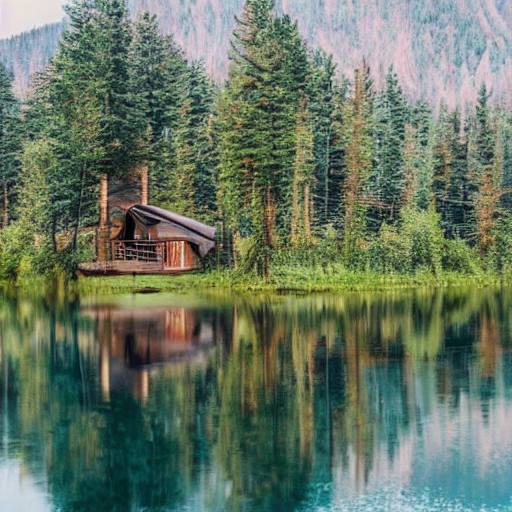

**primary_image.png** — 512×512, PNG; джерело: `labs/lab04_stable_diffusion/outputs/images/styles/photorealistic_seed42_steps30_cfg7p5_df410b01ba0eea49.png`. SHA-256: `1fc881e5282f86a05f3abb98201985881a331a5241cd404bf9e2b560b5bb08c5`.

In [3]:
source = json.loads((LAB_ROOT / "assets/input/source.json").read_text())
display(Image(filename=str(INPUT_IMAGE_PATH)))
display(Markdown(f"**{source['filename']}** — {source['width']}×{source['height']}, {source['format']}; "
                 f"джерело: `{source['source_path_or_url']}`. SHA-256: `{source['sha256']}`."))

## 4. Використана модель LLaVA

Модель завантажується лише за відсутності потрібних результатів. Першим іде fact_01 — smoke test, який зберігається у baseline. Вивід нижче — metadata справжнього завантаження моделі. Підклас pipeline лише додає вимірювання токенів та EOS до стандартного postprocess; генерацію він не змінює. Ваги, source metadata та імена файлів не підставляються у текст запитання.

In [4]:
rows = run_experiments()
model_info = json.loads((OUTPUT_ROOT / "metadata/model.json").read_text())
display(pd.DataFrame([{k: model_info[k] for k in [
    "model_id", "model_class", "pipeline_base_class", "dtype", "device_strategy",
    "vision_backbone", "language_backbone", "parameter_count"
]}]).T.rename(columns={0: "Значення"}))
print("Revision:", model_info["revision"])
print("Processor size:", model_info["image_processor"]["size"])
print("Model loading seconds (original run):", model_info["model_load_seconds"])

Complete: 19 experiment rows, 17 unique generations.


,Значення
model_id,llava-hf/llava-interleave-qwen-0.5b-hf
model_class,LlavaForConditionalGeneration
pipeline_base_class,ImageTextToTextPipeline
dtype,torch.float16
device_strategy,cuda:0
vision_backbone,siglip_vision_model
language_backbone,qwen2
parameter_count,864031264


Revision: 1090956dd1c79bc93ae98dcf395590369435ec91
Processor size: {'height': 384, 'width': 384}
Model loading seconds (original run): 7.556695499981288


## 5. Набір VQA-запитань

Три описові, три фактологічні, три аналітичні та один контроль без доступної з пікселів відповіді. Питання англійською; усі отримують ту саму grounding-інструкцію.

In [5]:
questions = pd.DataFrame(load_questions())
display(questions[["question_id", "question_type", "question", "answerable"]])
from labs.lab05_multimodal.src.config import GROUNDING_INSTRUCTION
print(GROUNDING_INSTRUCTION)

,question_id,question_type,question,answerable
0,desc_01,descriptive,Describe the main scene in this image in two sentences.,True
1,desc_02,descriptive,Describe the visible exterior of the cabin.,True
2,desc_03,descriptive,"Describe how the water, cabin, and trees are arranged in the image.",True
3,fact_01,factual,"Is the cabin on the left, in the center, or on the right side of the image?",True
4,fact_02,factual,What is the dominant color of the cabin's wooden walls?,True
5,fact_03,factual,Are reflections of trees visible in the water?,True
6,analysis_01,analytical,"Does the water appear calm or rough, and what visible evidence supports your answer?",True
7,analysis_02,analytical,"Does this scene appear urban or natural, and which visible features support that interpretation?",True
8,analysis_03,analytical,Why do the shapes in the lower half of the image look like reflections rather than additional upright trees? Cite visible clues.,True
9,control_01,unanswerable,What are the exact geographic coordinates of this cabin?,False


Answer using only information visible in the image. If the answer cannot be determined from the image, explicitly say so. Answer concisely and do not invent details.


## 6. Базовий експеримент

Greedy: do_sample=False, max_new_tokens=64, без temperature/top_p. Нижче 10 відповідей з оригінальними затримками inference, а не швидкістю читання кешу. 19 експериментальних рядків представляють 17 унікальних генерацій.

In [6]:
results = evaluated_results(rows)
assert not (results.evaluation_label == "NOT_REVIEWED").any(), "Нові відповіді потребують ручної оцінки перед використанням висновків"
baseline = results[results.experiment == "baseline"]
assert len(baseline) == 10
print("Unique generations:", results.run_id.nunique())
display(table(results, "baseline"))

Unique generations: 17


,question_id,question_type,question,answer,evaluation_label,runtime_seconds
0,fact_01,factual,"Is the cabin on the left, in the center, or on the right side of the image?",left,CORRECT,2.075005
1,desc_01,descriptive,Describe the main scene in this image in two sentences.,"The image shows a cabin nestled among trees on a lake, with a reflection of the cabin in the water. The cabin has a wooden roof and a small deck. The surrounding environment is lush with green trees and mountains in the background.",HALLUCINATED_DETAIL,2.786693
2,desc_02,descriptive,Describe the visible exterior of the cabin.,The cabin has a dark roof and a wooden frame.,GROUNDED,0.832531
3,desc_03,descriptive,"Describe how the water, cabin, and trees are arranged in the image.","The water is calm, reflecting the cabin and trees. The cabin is situated on a lake, surrounded by tall trees. The cabin is surrounded by a forest, with the lake reflecting the surrounding greenery.",MOSTLY_GROUNDED,2.411651
4,fact_02,factual,What is the dominant color of the cabin's wooden walls?,Brown,CORRECT,0.339019
5,fact_03,factual,Are reflections of trees visible in the water?,Yes,CORRECT,0.243154
6,analysis_01,analytical,"Does the water appear calm or rough, and what visible evidence supports your answer?","The water appears calm, and there is visible evidence of a calm lake.",PARTLY_SUPPORTED,0.943797
7,analysis_02,analytical,"Does this scene appear urban or natural, and which visible features support that interpretation?","This scene appears natural, and the visible features that support this interpretation include the presence of a lake, a forest, and a mountain in the background.",SUPPORTED_BY_VISIBLE_EVIDENCE,2.524978
8,analysis_03,analytical,Why do the shapes in the lower half of the image look like reflections rather than additional upright trees? Cite visible clues.,"The shapes in the lower half of the image are reflections of the trees because the image is a photograph of a forest with a lake. The reflection of the trees is the reflection of the trees themselves, not additional upright trees.",PARTLY_SUPPORTED,2.798139
9,control_01,unanswerable,What are the exact geographic coordinates of this cabin?,"[0.542,0.544,0.856,0.731]",HALLUCINATED,1.497136


## 7. Описові питання

Модель розпізнала будинок, дерева, водойму та відбиття. В desc_01 непідтверджено названо матеріал даху wooden, і замість двох речень отримано три. Desc_02 короткий, але підтверджений. Desc_03 пропускає запитані просторові деталі й неточно каже on a lake замість біля берега.

In [7]:
display(baseline.loc[baseline.question_type == "descriptive", ["question_id", "answer", "evaluation_label", "notes"]])

,question_id,answer,evaluation_label,notes
1,desc_01,"The image shows a cabin nestled among trees on a lake, with a reflection of the cabin in the water. The cabin has a wooden roof and a small deck. The surrounding environment is lush with green trees and mountains in the background.",HALLUCINATED_DETAIL,"Основні об’єкти названо правильно, але матеріал даху wooden не можна надійно встановити з пікселів. Замість запитаних двох речень отримано три."
2,desc_02,The cabin has a dark roof and a wooden frame.,GROUNDED,"Темний дах і дерев’яна конструкція видимі; відповідь коротка та неповна, але без явних вигадок."
3,desc_03,"The water is calm, reflecting the cabin and trees. The cabin is situated on a lake, surrounded by tall trees. The cabin is surrounded by a forest, with the lake reflecting the surrounding greenery.",MOSTLY_GROUNDED,"Вода, дерева й відбиття описані правильно; не зазначено ліве розташування будинку та передній план водойми. Формулювання on a lake неточне: будинок стоїть біля берега."


## 8. Фактологічні питання

Baseline: CORRECT=3, PARTIALLY_CORRECT=0, INCORRECT=0. Відповіді left, Brown, Yes відповідають видимим фактам. Це три прості цільові питання до одного кадру; результат не оцінює загальну точність LLaVA.

In [8]:
display(baseline.loc[baseline.question_type == "factual", ["question_id", "answer", "evaluation_label", "notes"]])

,question_id,answer,evaluation_label,notes
0,fact_01,left,CORRECT,Будиночок чітко розташований у лівій половині кадру.
4,fact_02,Brown,CORRECT,"Видимі дерев’яні стіни коричневі; оцінюється колір стін, не даху."
5,fact_03,Yes,CORRECT,У передньому плані видно відбиття дерев у воді.


## 9. Аналітичні питання

Analysis_02 підкріплює природний характер сцени видимими об’єктами. Analysis_01 повторює висновок calm замість доказу. Analysis_03 правильно називає відбиття, але не пояснює перевернуті форми чи відповідність деревам над берегом. Отже, правильна категорія відповіді ще не означає якісного міркування.

In [9]:
display(baseline.loc[baseline.question_type == "analytical", ["question_id", "answer", "evaluation_label", "notes"]])

,question_id,answer,evaluation_label,notes
6,analysis_01,"The water appears calm, and there is visible evidence of a calm lake.",PARTLY_SUPPORTED,"Висновок про спокійну воду прийнятний, але calm lake повторює висновок замість наведення конкретної ознаки."
7,analysis_02,"This scene appears natural, and the visible features that support this interpretation include the presence of a lake, a forest, and a mountain in the background.",SUPPORTED_BY_VISIBLE_EVIDENCE,"Природне середовище обґрунтовано водоймою, лісом і схилом на тлі. Точна географія не названа."
8,analysis_03,"The shapes in the lower half of the image are reflections of the trees because the image is a photograph of a forest with a lake. The reflection of the trees is the reflection of the trees themselves, not additional upright trees.",PARTLY_SUPPORTED,"Відбиття визначено правильно, проте відповідь тавтологічна: не пояснює перевертання форм чи їх відповідність деревам над берегом. Називання зображення фотографією не підтверджує його походження; воно згенероване."


## 10. Контрольне питання без відповіді

На природне запитання про точні географічні координати модель відповіла [0.542,0.544,0.856,0.731]. Чотири числа не є обґрунтованою відповіддю про місце; їх значення невідоме. За заданою рубрикою це HALLUCINATED: модель не визнала відсутність інформації попри спільну grounding-інструкцію. Числа нагадують рамку об’єкта, але таке походження не встановлено.

In [10]:
display(baseline.loc[baseline.question_type == "unanswerable", ["question_id", "answer", "evaluation_label", "notes"]])

,question_id,answer,evaluation_label,notes
9,control_01,"[0.542,0.544,0.856,0.731]",HALLUCINATED,"Замість визнання невизначеності подано чотири числа без джерела. Вони нагадують координати рамки, але їх значення невідоме; це не обґрунтовані географічні координати."


## 11. Вплив temperature

analysis_01; do_sample=True, top_p=0.9, max_new_tokens=64; seed=42 скидається перед кожним викликом; змінюється лише temperature.

За 0.2, 0.7 і 1.0 відповідь семантично стабільна: вода спокійна, видима опора — відбиття будинку й дерев. Довжини становлять 19, 23 і 23 токени включно з EOS; формулювання відрізняються, нових непідтверджених фактів немає. Погіршення за більшої температури тут не спостерігається. По одному seed на умову не дозволяє оцінити розподіл відповідей або загальну частоту галюцинацій. Baseline з greedy не входить до температурного sweep, бо відрізняється режим декодування.

In [11]:
display(table(results, "temperature"))

,temperature,answer,runtime_seconds,generated_token_count,evaluation_label
0,0.2,"The water appears calm, and the reflection of the cabin and the surrounding trees is visible.",1.847052,19,SUPPORTED_BY_VISIBLE_EVIDENCE
1,0.7,"The water appears calm, and visible evidence of calmness is the reflection of the cabin and the surrounding trees.",1.428257,23,SUPPORTED_BY_VISIBLE_EVIDENCE
2,1.0,The water appears calm. This is evident from the reflection of the cabin and trees on the water's surface.,1.391898,23,SUPPORTED_BY_VISIBLE_EVIDENCE


## 12. Вплив max_new_tokens

desc_01; greedy; змінюється лише ліміт 24/64/128. Кількість токенів виміряна за continuation, включно з EOS.

За 24 токени продовження обірвано на The cabin, EOS відсутній. За лімітів 64 і 128 отримано дослівно однакову завершену відповідь із 48 токенів включно з EOS. Додатковий бюджет не усунув непідтверджений матеріал даху. max_new_tokens є верхньою межею довжини, не бажаною довжиною і не гарантією якості. Рядок 64 повторно використовує baseline desc_01.

In [12]:
display(table(results, "max_tokens"))

,max_new_tokens,answer,generated_token_count,runtime_seconds,reached_token_limit
0,24,"The image shows a cabin nestled among trees on a lake, with a reflection of the cabin in the water. The cabin",24,1.379227,True
1,64,"The image shows a cabin nestled among trees on a lake, with a reflection of the cabin in the water. The cabin has a wooden roof and a small deck. The surrounding environment is lush with green trees and mountains in the background.",48,2.786693,False
2,128,"The image shows a cabin nestled among trees on a lake, with a reflection of the cabin in the water. The cabin has a wooden roof and a small deck. The surrounding environment is lush with green trees and mountains in the background.",48,2.613787,False


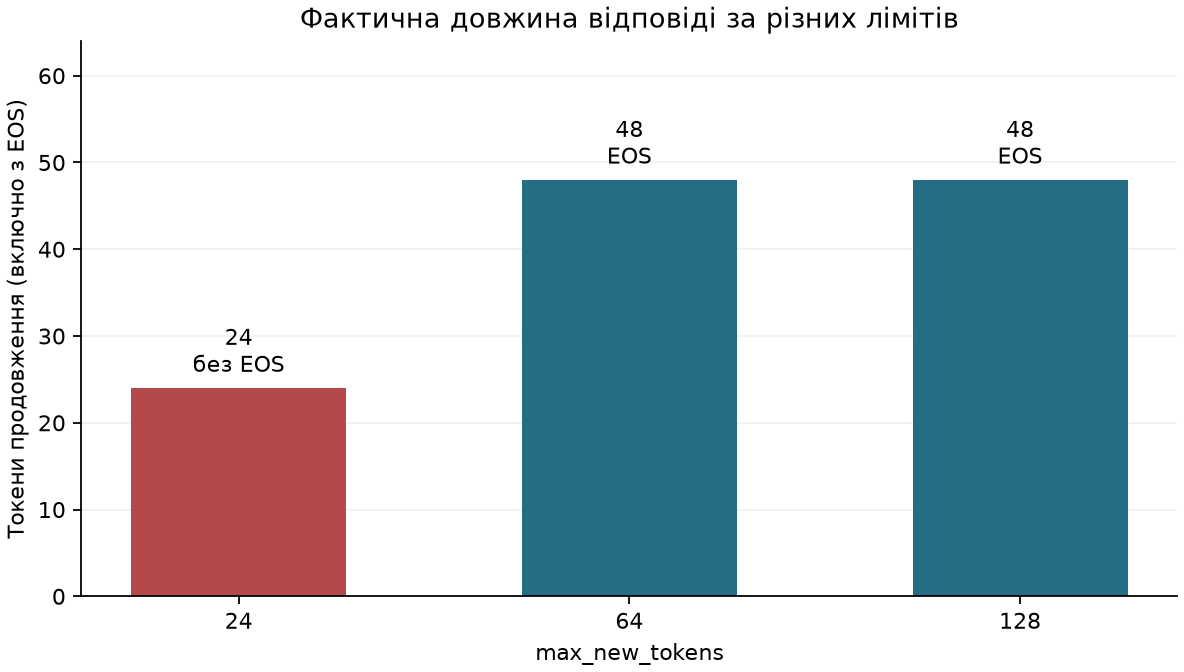

In [13]:
figure_path = build_figure(results)
display(Image(filename=str(figure_path)))

## 13. Узгодженість перефразованих питань

Три рівнозначні формулювання про горизонтальне положення будиночка. Однакові greedy-параметри.

Три рівнозначні запитання про горизонтальне положення дали left, center, Left. Перше й третє семантично узгоджені й правильні; друге хибне. Повної узгодженості немає, хоча всі параметри greedy однакові. Зміна регістру не є відмінністю змісту. Перший рядок повторно використовує baseline fact_01.

In [14]:
display(table(results, "paraphrase"))

,case_id,question,answer,evaluation_label,notes
0,phrasing_1,"Is the cabin on the left, in the center, or on the right side of the image?",left,CORRECT,Будиночок чітко розташований у лівій половині кадру.
1,phrasing_2,"Where is the cabin located horizontally in the image: left, center, or right?",center,INCORRECT,Center суперечить зображенню: будинок ліворуч.
2,phrasing_3,"Which horizontal part of the image contains the cabin: left, center, or right?",Left,CORRECT,Left правильно вказує на ліву частину кадру.


## 14. Зведена оцінка

Оцінювання виконане асистентом вручну після перегляду зображення й кожної відповіді; це не незалежна експертна розмітка. Для фактів: CORRECT — правильна відповідь, PARTIALLY_CORRECT — частково правильна, INCORRECT — суперечить зображенню. Для описів: GROUNDED — підтверджений пікселями, MOSTLY_GROUNDED — переважно підтверджений із неточностями, HALLUCINATED_DETAIL — містить непідтверджену деталь. Для аналізу: SUPPORTED_BY_VISIBLE_EVIDENCE, PARTLY_SUPPORTED, UNSUPPORTED_SPECULATION розрізняють наявність конкретних візуальних доказів. Для контролю: CORRECT_UNCERTAINTY або HALLUCINATED. Неповнота відповіді та галюцинація — різні недоліки.

Точність підраховується тільки для трьох фактологічних baseline-питань. Контрольне питання, описові й аналітичні відповіді до цього знаменника не входять. У report/manual_evaluation.json збережено зв’язок оцінки з run_id, дослівною відповіддю і SHA зображення; зміна відповіді унеможливлює непомітне повторне використання старої оцінки.

In [15]:
display(factual_summary(results))
display(baseline[["question_id", "question_type", "evaluation_label", "notes"]])

,count
evaluation_label,
CORRECT,3
PARTIALLY_CORRECT,0
INCORRECT,0
NOT_REVIEWED,0


,question_id,question_type,evaluation_label,notes
0,fact_01,factual,CORRECT,Будиночок чітко розташований у лівій половині кадру.
1,desc_01,descriptive,HALLUCINATED_DETAIL,"Основні об’єкти названо правильно, але матеріал даху wooden не можна надійно встановити з пікселів. Замість запитаних двох речень отримано три."
2,desc_02,descriptive,GROUNDED,"Темний дах і дерев’яна конструкція видимі; відповідь коротка та неповна, але без явних вигадок."
3,desc_03,descriptive,MOSTLY_GROUNDED,"Вода, дерева й відбиття описані правильно; не зазначено ліве розташування будинку та передній план водойми. Формулювання on a lake неточне: будинок стоїть біля берега."
4,fact_02,factual,CORRECT,"Видимі дерев’яні стіни коричневі; оцінюється колір стін, не даху."
5,fact_03,factual,CORRECT,У передньому плані видно відбиття дерев у воді.
6,analysis_01,analytical,PARTLY_SUPPORTED,"Висновок про спокійну воду прийнятний, але calm lake повторює висновок замість наведення конкретної ознаки."
7,analysis_02,analytical,SUPPORTED_BY_VISIBLE_EVIDENCE,"Природне середовище обґрунтовано водоймою, лісом і схилом на тлі. Точна географія не названа."
8,analysis_03,analytical,PARTLY_SUPPORTED,"Відбиття визначено правильно, проте відповідь тавтологічна: не пояснює перевертання форм чи їх відповідність деревам над берегом. Називання зображення фотографією не підтверджує його походження; воно згенероване."
9,control_01,unanswerable,HALLUCINATED,"Замість визнання невизначеності подано чотири числа без джерела. Вони нагадують координати рамки, але їх значення невідоме; це не обґрунтовані географічні координати."


## 15. Обмеження

Один синтетичний кадр, три прості факти та одна реалізація sampling для кожної температури — малий навчальний експеримент. Обробка до 384×384 може втрачати дрібні деталі. Невелика мовна основа та мультимодальне узгодження не гарантують правильних просторових відповідей чи аргументації. Ручні якісні оцінки залежать від інтерпретації; оцінка матеріалу даху свідомо консервативна. Точний час, координати, люди поза кадром і фактичне походження сцени не доступні моделі з пікселів.

Однаковий seed скидається перед кожним sampling-викликом, але версії бібліотек, GPU, числова точність та реалізація kernels можуть змінювати результати. Час виміряно з CUDA synchronization; завантаження моделі виключено. Перший fact_01 включає прогрівання. Окремі затримки не є benchmark швидкодії. Веб використовувався лише для перевірки документації та завантаження ваг, а не для відповідей VQA.

## 16. Висновки

LLaVA розпізнає головний зміст цього зображення та відповідає правильно на три базові факти, але аналітичні пояснення часто поверхові. Контроль координат виявив непідтверджену числову відповідь, а перефразування змінило правильне left на хибне center. Отже, baseline 3/3 не означає надійності за іншого формулювання.

У температурному sweep усі три відповіді залишилися візуально обґрунтованими. Ліміт 24 токени спричинив обрив, 64 і 128 дали однаковий текст із природним завершенням. На цьому прикладі більший бюджет не покращив зміст. Компактна модель придатна для демонстрації мультимодального inference на GPU 4 ГБ, але її точні твердження та пояснення потребують перевірки за зображенням.

[Звіт](../report/report.md) · [Контрольні запитання](../report/defense_notes.md) · [Аудит методики](../report/methodology_audit.md)